<a href="https://colab.research.google.com/github/MuhammadUsmanManzoor/MachineVision/blob/main/ML4CV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q transformers torch pillow requests

In [2]:
image_urls = [
    "http://images.cocodataset.org/val2017/000000039769.jpg",  # cats
    "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/cats.png",
    "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/transformers/tasks/car.jpg"
]

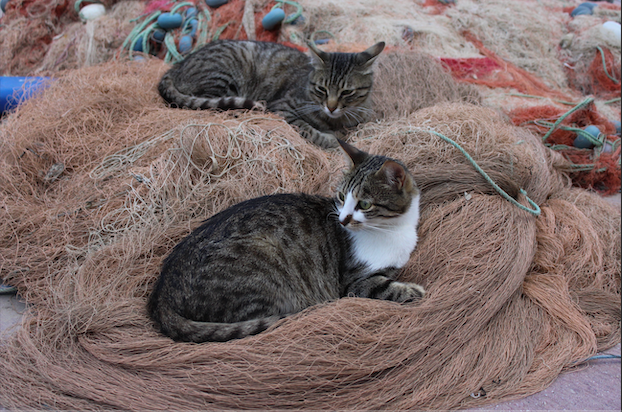

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


tabby, tabby cat - 0.2769
tiger cat - 0.2764
Egyptian cat - 0.1403
hay - 0.0253
wool, woolen, woollen - 0.0199


In [4]:
from transformers import pipeline
from PIL import Image
import requests
from IPython.display import display

# Choose image URL
url = "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/cats.png"

# Load image from URL
image = Image.open(requests.get(url, stream=True).raw).convert("RGB")

# Display image
display(image)

# Load Vision Transformer classifier
classifier = pipeline(
    "image-classification",
    model="google/vit-base-patch16-224"
)

# Predict
predictions = classifier(image)

# Show top 5 predictions
for pred in predictions[:5]:
    print(f"{pred['label']} - {pred['score']:.4f}")